<a href="https://www.kaggle.com/code/shashikalarajesh11/missing-indicator-random-sample-imputation?scriptVersionId=332756322" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Special Technique for handling both missing values for numerical and categorical data (Univariate)

## 1#Random Value Imputation 
## 2#Missing Imputer
## 3#Automatic Selection of parameter

## Random Imputation:

1. Preserves the variance of the variable (but why?)
2. Memory heavy for deployment, as we need to store the original training set to extract values from and replace the NA in coming observations.
3. Well suited for linear models as it does not distort the distribution, regardless of the % of NA

### Benefits of Random Imputation:

1. Easy to implement (can be used using only pandas not sklearn)
2. variance and distribution are intact

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/kaggle/input/datasets/shashikalarajesh11/titanic-dataset/Titanic-Dataset.csv',usecols=['Age','Fare','Survived'])

df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [3]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [4]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [5]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [6]:
x_train['Age_imputed']=x_train['Age']
x_test['Age_imputed']=x_test['Age']

In [7]:
x_train['Age'].isnull().sum()

np.int64(148)

In [8]:
x_train['Age_imputed'].isnull().sum()

np.int64(148)

In [9]:
print(x_train['Age'].isnull().sum())
print(x_train['Age_imputed'].isnull().sum())
print(x_train['Age'].equals(x_train['Age_imputed']))

148
148
True


In [10]:
x_train.head()

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0


In [11]:
x_test.head()

,Age,Fare,Age_imputed
707,42.0,26.2875,42.0
37,21.0,8.0500,21.0
615,24.0,65.0000,24.0
169,28.0,56.4958,28.0
68,17.0,7.9250,17.0


In [12]:
x_train.loc[x_train['Age_imputed'].isnull(), 'Age_imputed'] = (
    x_train['Age']
    .dropna()
    .sample(x_train['Age'].isnull().sum(), random_state=42)
    .values
)

x_test.loc[x_test['Age_imputed'].isnull(), 'Age_imputed'] = (
    x_train['Age']
    .dropna()
    .sample(x_test['Age'].isnull().sum(), random_state=42)
    .values
)

/tmp/ipykernel_16/2477327225.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'],label='Original',hist=False)
/tmp/ipykernel_16/2477327225.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age_imputed'],label='Imputed',hist=False)


<Axes: xlabel='Age_imputed', ylabel='Density'>

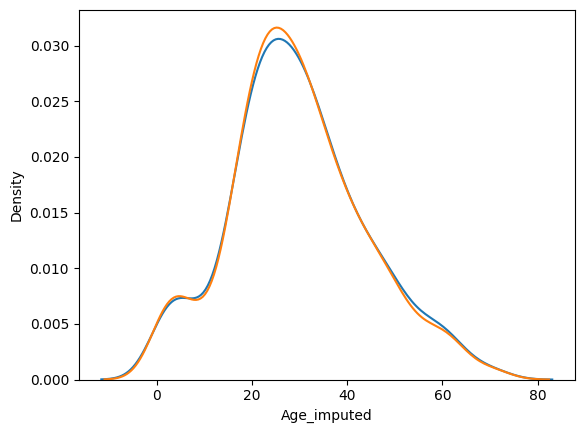

In [13]:
sns.distplot(x_train['Age'],label='Original',hist=False)
sns.distplot(x_train['Age_imputed'],label='Imputed',hist=False)

In [14]:
print('Original variable variance:',x_train['Age'].var())
print('Variance after random imputation:',x_train['Age_imputed'].var())

Original variable variance: 204.3495133904614
Variance after random imputation: 200.02896637747125


In [15]:
x_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,53.259863
Age,71.512440,204.349513,204.349513
Age_imputed,53.259863,204.349513,200.028966


<Axes: >

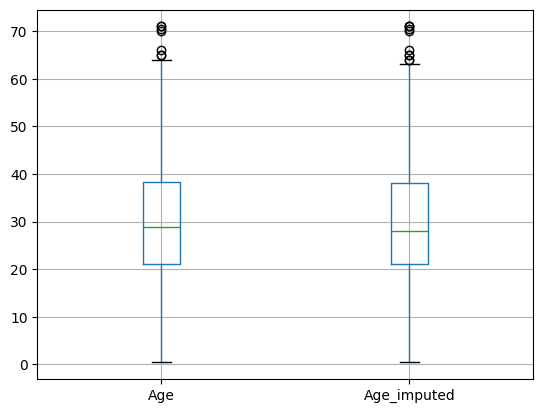

In [16]:
x_train[['Age','Age_imputed']].boxplot()

In [17]:
# sample_value=x_train['Age'].dropna().sample(1,random_state=int(observation['Fare']))

In [18]:
data=pd.read_csv('/kaggle/input/datasets/shashikalarajesh11/housing-dataset/train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [19]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [20]:
x=data
y=data['SalePrice']

In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [22]:
x_train['GarageQual_imputed']=x_train['GarageQual']
x_test['GarageQual_imputed']=x_test['GarageQual']

x_train['FireplaceQu_imputed']=x_train['FireplaceQu']
x_test['FireplaceQu_imputed']=x_test['FireplaceQu']

In [23]:
x_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
271,TA,TA,241500,TA,TA
1315,Gd,TA,206900,TA,Gd
170,NaN,TA,128500,TA,NaN
1426,TA,TA,271000,TA,TA
912,NaN,TA,88000,TA,NaN


In [24]:
x_train.loc[x_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = (
    x_train['GarageQual']
    .dropna()
    .sample(x_train['GarageQual'].isnull().sum(), random_state=42)
    .values
)

x_test.loc[x_test['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = (
    x_train['FireplaceQu']
    .dropna()
    .sample(x_test['FireplaceQu'].isnull().sum(), random_state=42)
    .values
)

In [25]:
temp=pd.concat(
    [
        x_train['GarageQual'].value_counts()/len(x_train['GarageQual'].dropna()),
        x_train['GarageQual_imputed'].value_counts()/len(data)
    ],axis=1
)

temp.columns=['original','imputed']
temp

,original,imputed
TA,0.951043,0.761644
Fa,0.037171,0.029452
Gd,0.009973,0.007534
Po,0.000907,0.000685
Ex,0.000907,0.000685


In [26]:
temp=pd.concat(
    [
        x_train['FireplaceQu'].value_counts()/len(x_train['FireplaceQu'].dropna()),
        x_train['FireplaceQu_imputed'].value_counts()/len(data)
    ],axis=1
)

temp.columns=['original','imputed']
temp

,original,imputed
Gd,0.494272,0.206849
TA,0.412439,0.172603
Fa,0.040917,0.017123
Po,0.027823,0.011644
Ex,0.024550,0.010274


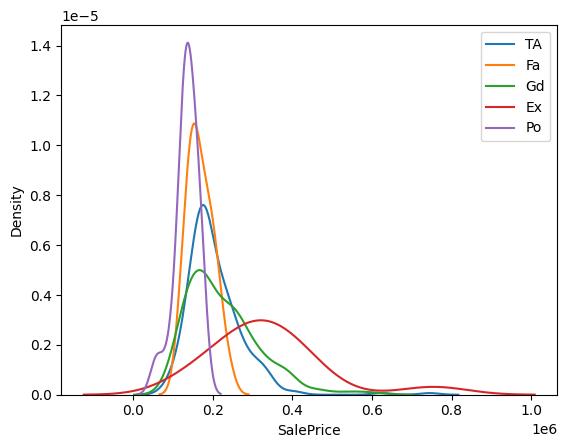

In [27]:
for category in x_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(
        data=x_train[x_train['FireplaceQu'] == category],
        x='SalePrice',
        label=category
    )

plt.legend()
plt.show()

/tmp/ipykernel_16/2751722281.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_16/2751722281.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


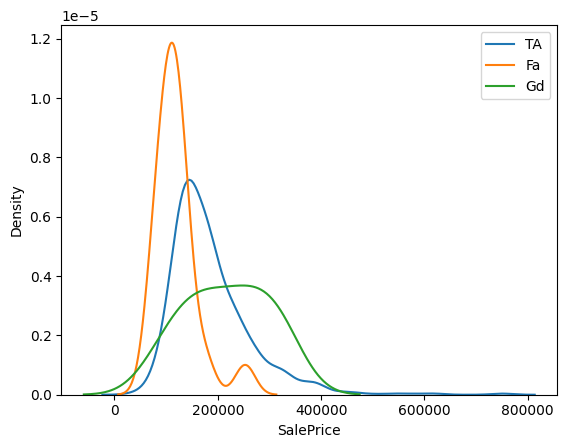

In [28]:
for category in x_train['GarageQual'].dropna().unique():
    sns.kdeplot(
        data=x_train[x_train['GarageQual'] == category],
        x='SalePrice',
        label=category
    )

plt.legend()
plt.show()

# Missing Indicator

In [29]:
df=pd.read_csv('/kaggle/input/datasets/shashikalarajesh11/titanic-dataset/Titanic-Dataset.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [30]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [31]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [32]:
x_train.head()

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458


In [33]:
from sklearn.impute import SimpleImputer,MissingIndicator

In [34]:
si=SimpleImputer()
x_train_trf=si.fit_transform(x_train)
x_test_trf=si.transform(x_test)

In [35]:
from sklearn.linear_model import LogisticRegression

clf=LogisticRegression()
clf.fit(x_train_trf,y_train)

y_pred=clf.predict(x_test_trf)

from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.6145251396648045

In [36]:
mi=MissingIndicator()
mi.fit(x_train)

MissingIndicator()

In [37]:
mi.features_

array([0])

In [38]:
x_train_missing=mi.transform(x_train)

In [39]:
x_test_missing=mi.transform(x_test)

In [40]:
x_test_missing

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [

In [41]:
x_train['Age_NA']=x_train_missing
x_test['Age_NA']=x_test_missing

In [42]:
x_train

,Age,Fare,Age_NA
30,40.0,27.7208,False
10,4.0,16.7000,False
873,47.0,9.0000,False
182,9.0,31.3875,False
876,20.0,9.8458,False
...,...,...,...
534,30.0,8.6625,False
584,NaN,8.7125,True
493,71.0,49.5042,False
527,NaN,221.7792,True


In [43]:
si=SimpleImputer()
x_train_trf2=si.fit_transform(x_train)
x_test_trf2=si.transform(x_test)

In [44]:
from sklearn.linear_model import LogisticRegression

clf=LogisticRegression()
clf.fit(x_train_trf2,y_train)
y_pred=clf.predict(x_test_trf2)

from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.6312849162011173

In [45]:
si=SimpleImputer(add_indicator=True)
x_train=si.fit_transform(x_train)
x_test=si.transform(x_test)

In [46]:
from sklearn.linear_model import LogisticRegression

clf=LogisticRegression()
clf.fit(x_train_trf2,y_train)

y_pred=clf.predict(x_test_trf2)

from sklearn.metrics import accuracy_score 
accuracy_score(y_test,y_pred)

0.6312849162011173

# Automatically select value for Imputation

- We use technique called 'Grid Search CV'

In [47]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split,GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LogisticRegression

In [48]:
df=pd.read_csv('/kaggle/input/datasets/shashikalarajesh11/titanic-dataset/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [49]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [50]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [51]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)
x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
30,1,male,40.0,0,0,27.7208,C
10,3,female,4.0,1,1,16.7000,S
873,3,male,47.0,0,0,9.0000,S
182,3,male,9.0,4,2,31.3875,S
876,3,male,20.0,0,0,9.8458,S


In [52]:
numerical_features=['Age','Fare']
numerical_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

categorical_features=['Embarked','Sex']
categorical_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('ohe',OneHotEncoder(handle_unknown='ignore'))
])


In [53]:
preprocessor=ColumnTransformer(
    transformers=[
        ('num',numerical_transformer,numerical_features),
        ('cat',categorical_transformer,categorical_features)
    ]
)

In [54]:
clf=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',LogisticRegression())
])

In [55]:
from sklearn import set_config

set_config(display='diagram')
clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Embarked', 'Sex'])])),
                ('classifier', LogisticRegression())])

In [56]:
param_grid={
    'preprocessor__num__imputer__strategy':['mean','median'],
    'preprocessor__cat__imputer__strategy':['most_frequent','constant'],
    'classifier__C':[0.1,1.0,10,100]
}

grid_search=GridSearchCV(clf,param_grid,cv=10)

In [57]:
grid_search.fit(x_train,y_train)
print(f'Best params:')
print(grid_search.best_params_)

Best params:
{'classifier__C': 1.0, 'preprocessor__cat__imputer__strategy': 'most_frequent', 'preprocessor__num__imputer__strategy': 'mean'}


In [58]:
print(f'Internal CV score:{grid_search.best_score_:.3f}')

Internal CV score:0.788


In [59]:
import pandas as pd

cv_results=pd.DataFrame(grid_search.cv_results_)
cv_results=cv_results.sort_values('mean_test_score',ascending=False)
cv_results[['param_classifier__C','param_preprocessor__cat__imputer__strategy','param_preprocessor__num__imputer__strategy','mean_test_score']]

,param_classifier__C,param_preprocessor__cat__imputer__strategy,param_preprocessor__num__imputer__strategy,mean_test_score
7,1.0,constant,median,0.787852
6,1.0,constant,mean,0.787852
5,1.0,most_frequent,median,0.787852
4,1.0,most_frequent,mean,0.787852
11,10.0,constant,median,0.787852
10,10.0,constant,mean,0.787852
9,10.0,most_frequent,median,0.787852
8,10.0,most_frequent,mean,0.787852
12,100.0,most_frequent,mean,0.787852
13,100.0,most_frequent,median,0.787852
